# `PFNRBicop` Sinkhorn Projection Demo

This notebook demonstrates the effect of Sinkhorn projection in `PFNRBicop`. We fit one unconditional `PFNRBicop` model on data simulated from a Clayton copula, then evaluate `pdf_grid(...)` multiple times with different `sinkhorn_iters` overrides.

Goal:
Compare how well the estimated density satisfies the copula margin constraints
$$
  \int c(u, v) dv = 1, \quad
  \int c(u, v) du = 1
$$
as `sinkhorn_iters` increases.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvinecopulib as pv
from scipy.stats import kendalltau, norm

from npcc import PFNRBicop

## 1) Simulate training data from a Clayton copula

In [22]:
theta = 3.0
n_train = 1000

clayton = pv.Bicop(
    family=pv.BicopFamily.clayton,
    parameters=np.asarray([[theta]], dtype=np.float64),
)

uv_train = clayton.simulate(n=n_train, seeds=[2, 2, 4])
u = uv_train[:, 0]
v = uv_train[:, 1]

print(f"Generated samples: {uv_train.shape}")
print(f"Empirical Kendall tau: {kendalltau(u, v).statistic:.4f}")
print(f"Analytic Clayton tau: {theta / (theta + 2.0):.4f}")

Generated samples: (1000, 2)
Empirical Kendall tau: 0.6158
Analytic Clayton tau: 0.6000


## 2) Fit default `PFNRBicop` model without Sinkhorn projection

Sinkhorn is an optional evaluation-time correction, so fitting once and overriding `sinkhorn_iters` in the density calls isolates the effect of projection itself. By default no projection is done. Setting `sinkhorn_iters` to a positive integer at model initialization sets the number of iterations for PDF calls. This can be overridden in each PDF call.

In [ ]:
model = PFNRBicop(
    method="criterion",
    transform="logit",
    sinkhorn_iters=None,
)

model.fit(u, v)
print("Fitted PFNRBicop model.")

## 3) Evaluate pdf_grid on a common grid with different Sinkhorn iteration counts

In [24]:
grid_n = 101
u_grid = np.linspace(0.01, 0.99, grid_n)
v_grid = np.linspace(0.01, 0.99, grid_n)

iters_list = [None, 1, 3, 10]

densities = {}
for iters in iters_list:
    label = "none" if iters is None else str(iters)
    densities[label] = model.pdf_grid(
        u_grid,
        v_grid,
        sinkhorn_iters=iters,
    )

list(densities.keys())

['none', '1', '3', '10']

## 4) Margin diagnostics

In [25]:
def marginal_diagnostics(c: np.ndarray, u_grid: np.ndarray, v_grid: np.ndarray) -> dict[str, float]:
    # Integrate over v for each fixed u (row-wise)
    int_over_v = np.trapezoid(c, x=v_grid, axis=1)

    # Integrate over u for each fixed v (column-wise)
    int_over_u = np.trapezoid(c, x=u_grid, axis=0)

    err_rows = np.abs(int_over_v - 1.0)
    err_cols = np.abs(int_over_u - 1.0)

    return {
        "row_mean_abs_err": float(err_rows.mean()),
        "row_max_abs_err": float(err_rows.max()),
        "col_mean_abs_err": float(err_cols.mean()),
        "col_max_abs_err": float(err_cols.max()),
    }


report = pd.DataFrame(
    [
        {"sinkhorn_iters": label, **marginal_diagnostics(c, u_grid, v_grid)}
        for label, c in densities.items()
    ]
)

report = report.round(4)
report

,sinkhorn_iters,row_mean_abs_err,row_max_abs_err,col_mean_abs_err,col_max_abs_err
0,none,0.0291,0.4262,0.0281,0.4224
1,1,0.0126,0.1266,0.0000,0.0000
2,3,0.0043,0.0471,0.0000,0.0000
3,10,0.0014,0.0105,0.0000,0.0000


# 5) Plot the marginal integrals:

Left: $\int c(u, v) dv$ as a function of $u$
Right: $\int c(u, v) du$ as a function of $v$

The closer these curves are to $1$, the better the copula margin constraints are satisfied.

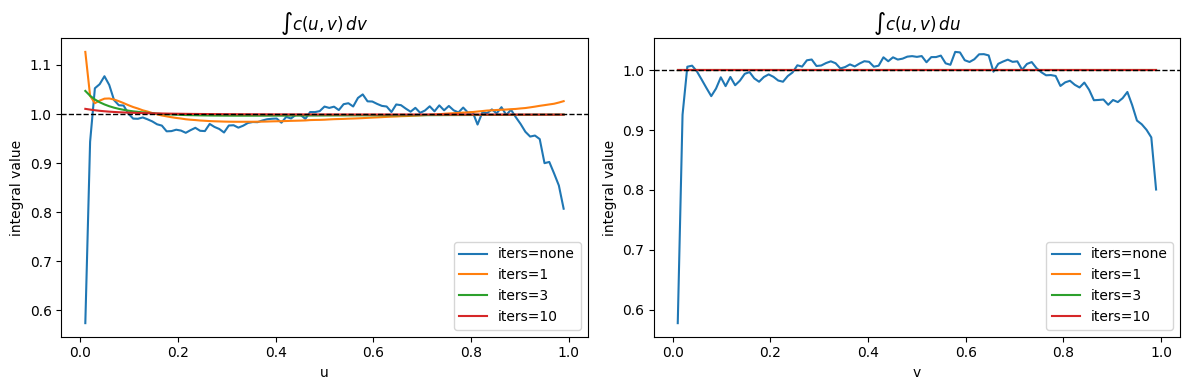

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, c in densities.items():
    int_over_v = np.trapezoid(c, x=v_grid, axis=1)
    int_over_u = np.trapezoid(c, x=u_grid, axis=0)

    axes[0].plot(u_grid, int_over_v, label=f"iters={label}")
    axes[1].plot(v_grid, int_over_u, label=f"iters={label}")

axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)

axes[0].set_title(r"$\int c(u,v)\,dv$")
axes[1].set_title(r"$\int c(u,v)\,du$")
axes[0].set_xlabel("u")
axes[1].set_xlabel("v")
axes[0].set_ylabel("integral value")
axes[1].set_ylabel("integral value")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()


 # 6) Contour plots of the density surface for a few Sinkhorn settings

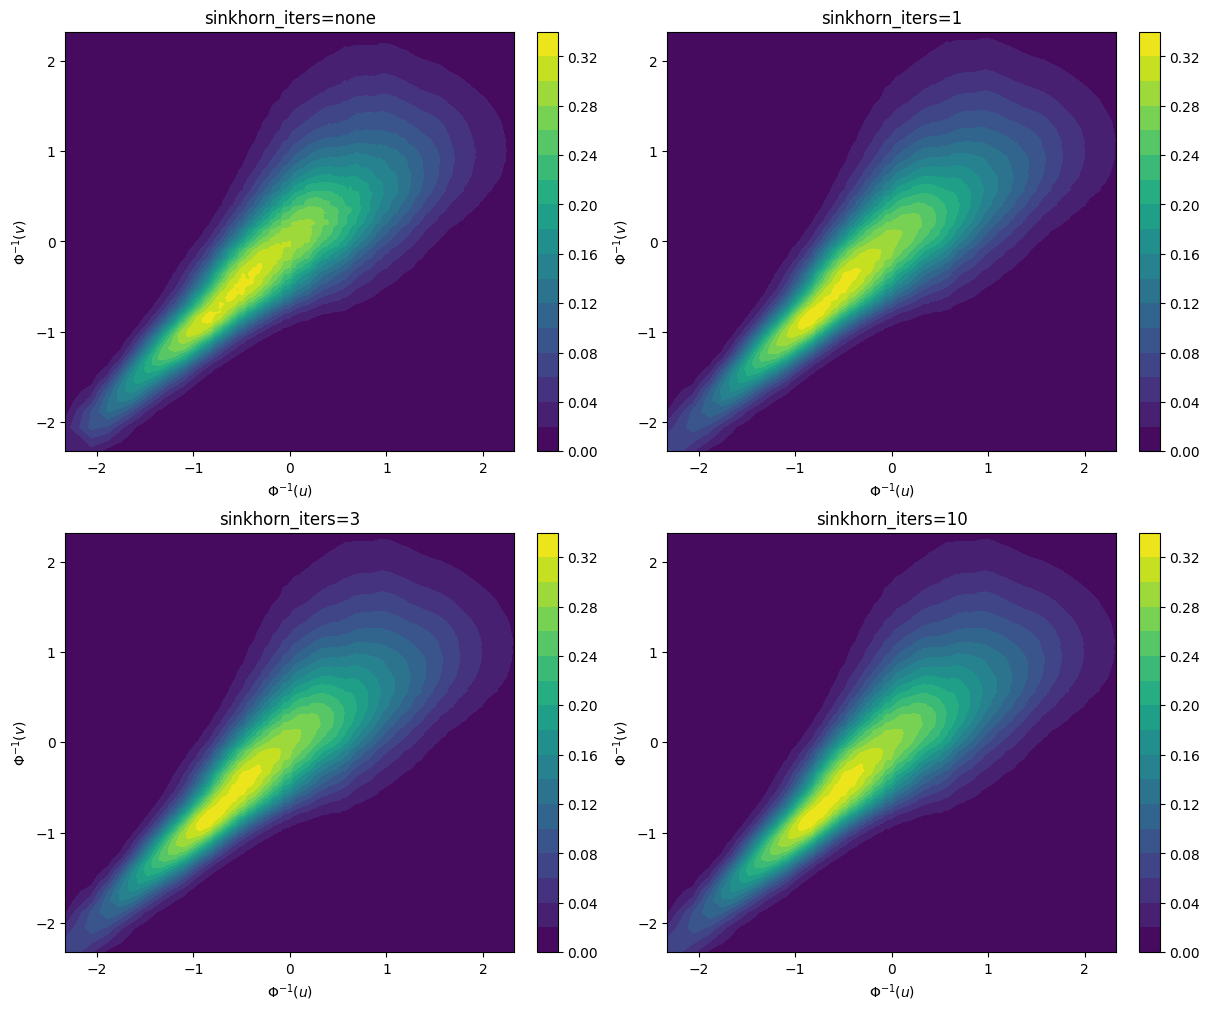

In [27]:
# Normal-score transformed grid for plotting
x_grid = norm.ppf(u_grid)
y_grid = norm.ppf(v_grid)

# Standard normal pdf values for Jacobian adjustment
phi_x = norm.pdf(x_grid)
phi_y = norm.pdf(y_grid)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for ax, label in zip(axes.ravel(), ["none", "1", "3", "10"]):
    c = densities[label]
    c_normal = c * phi_x[:, None] * phi_y[None, :]

    cs = ax.contourf(x_grid, y_grid, c_normal.T, levels=20)
    ax.set_title(f"sinkhorn_iters={label}")
    ax.set_xlabel(r"$\Phi^{-1}(u)$")
    ax.set_ylabel(r"$\Phi^{-1}(v)$")
    fig.colorbar(cs, ax=ax)

plt.show()

# 7) Simple convergence-style summary: how the marginal errors decrease with more Sinkhorn iterations


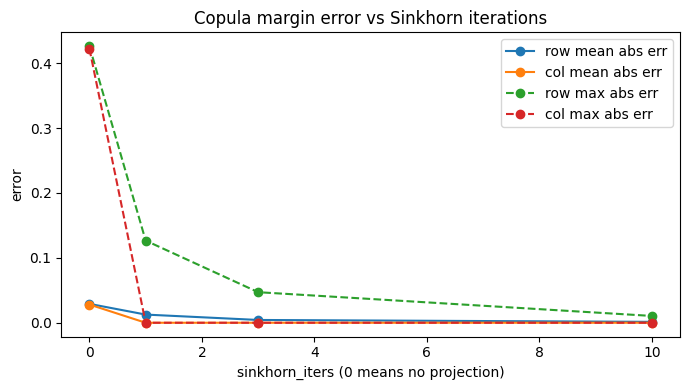

In [29]:
plot_df = report.copy()
plot_df["iters_numeric"] = plot_df["sinkhorn_iters"].replace({"none": 0}).astype(int)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(plot_df["iters_numeric"], plot_df["row_mean_abs_err"], marker="o", label="row mean abs err")
ax.plot(plot_df["iters_numeric"], plot_df["col_mean_abs_err"], marker="o", label="col mean abs err")
ax.plot(plot_df["iters_numeric"], plot_df["row_max_abs_err"], marker="o", linestyle="--", label="row max abs err")
ax.plot(plot_df["iters_numeric"], plot_df["col_max_abs_err"], marker="o", linestyle="--", label="col max abs err")

ax.set_xlabel("sinkhorn_iters (0 means no projection)")
ax.set_ylabel("error")
ax.set_title("Copula margin error vs Sinkhorn iterations")
ax.legend()

plt.tight_layout()
plt.show()